In [2]:
from vehicle_id.data.compcars_manifest import build_manifest
from vehicle_id.attributes.dataset import CompCarsMakeDataset

In [12]:
import pandas as pd
import cv2
import matplotlib.pyplot as plt
import ast
import re
from scipy.io import loadmat
import random
import os

In [2]:
label_path = "../../data/raw/compcars/label/1/1101/2011/3a62131af5fe8e.txt"  # adjust to a real path from your manifest
with open(label_path) as f:
    print(f.read())

4
1
85 107 682 469



In [4]:
from vehicle_id.data.compcars_manifest import build_manifest

df = build_manifest(
    image_root="../../data/raw/compcars/image",
    label_root="../../data/raw/compcars/label",
)

print(len(df))
df.head()

136726


,image_path,make_id,model_id,year,bbox,viewpoint,car_type,type
0,../../data/raw/compcars/image\1\1101\2011\07b9...,1,1101,2011,"(124, 33, 674, 480)",1,1,0
1,../../data/raw/compcars/image\1\1101\2011\2272...,1,1101,2011,"(52, 153, 849, 506)",4,1,0
2,../../data/raw/compcars/image\1\1101\2011\3a62...,1,1101,2011,"(85, 107, 682, 469)",4,1,0
3,../../data/raw/compcars/image\1\1101\2011\5133...,1,1101,2011,"(91, 23, 759, 551)",2,1,0
4,../../data/raw/compcars/image\1\1101\2011\6632...,1,1101,2011,"(58, 134, 707, 504)",5,1,0


In [ ]:
make_model = loadmat("../../data/raw/compcars/misc/make_model_name.mat")
print(make_model.keys())

car_type = loadmat("../../data/raw/compcars/misc/car_type.mat")
print(car_type.keys())

dict_keys(['__header__', '__version__', '__globals__', 'make_names', 'model_names'])
dict_keys(['__header__', '__version__', '__globals__', 'types'])


In [5]:
with open("../../data/raw/compcars/misc/attributes.txt") as f:
    for _ in range(5):
        print(f.readline())

model_id maximum_speed displacement door_number seat_number type

1 235 1.8 5 5 4

2 220 1.8 4 5 3

3 228 2.0 4 5 3

4 230 2.0 5 5 2



In [ ]:

df = pd.read_csv("../../data/manifests/compcars_manifest.csv")


def resolve_name(names_array, id_value):
    try:
        idx = int(id_value) - 1
        return str(names_array[idx][0])
    except (IndexError, ValueError, TypeError):
        return None

df["make_name"] = df["make_id"].apply(lambda x: resolve_name(make_model["make_names"], x))
df["model_name"] = df["model_id"].apply(lambda x: resolve_name(make_model["model_names"], x))
df["car_type_name"] = df["car_type"].apply(lambda x: resolve_name(car_type["types"], x))

df.head()

,image_path,make_id,model_id,year,bbox,viewpoint,car_type,make_name,model_name,car_type_name
0,../../data/raw/compcars/image\1\1101\2011\07b9...,1,1101,2011,"(124, 33, 674, 480)",1,1,['ABT'],['ABT A3'],['MPV']
1,../../data/raw/compcars/image\1\1101\2011\2272...,1,1101,2011,"(52, 153, 849, 506)",4,1,['ABT'],['ABT A3'],['MPV']
2,../../data/raw/compcars/image\1\1101\2011\3a62...,1,1101,2011,"(85, 107, 682, 469)",4,1,['ABT'],['ABT A3'],['MPV']
3,../../data/raw/compcars/image\1\1101\2011\5133...,1,1101,2011,"(91, 23, 759, 551)",2,1,['ABT'],['ABT A3'],['MPV']
4,../../data/raw/compcars/image\1\1101\2011\6632...,1,1101,2011,"(58, 134, 707, 504)",5,1,['ABT'],['ABT A3'],['MPV']


In [6]:
print(make_model["make_names"][:5])
print(make_model["model_names"][:5])
print(car_type["types"][:10])

[[array(['ABT'], dtype='<U3')]
 [array(['BAC'], dtype='<U3')]
 [array(['Conquest'], dtype='<U8')]
 [array(['DS'], dtype='<U2')]
 [array(['Dacia'], dtype='<U5')]]
[[array(['Audi A3 hatchback'], dtype='<U17')]
 [array(['Audi A4L'], dtype='<U8')]
 [array(['Audi A6L'], dtype='<U8')]
 [array(['Audi Q3'], dtype='<U7')]
 [array(['Audi Q5'], dtype='<U7')]]
[[array(['MPV'], dtype='<U3') array(['SUV'], dtype='<U3')
  array(['sedan'], dtype='<U5') array(['hatchback'], dtype='<U9')
  array(['minibus'], dtype='<U7') array(['fastback'], dtype='<U8')
  array(['estate'], dtype='<U6') array(['pickup'], dtype='<U6')
  array(['hardtop convertible'], dtype='<U19')
  array(['sports'], dtype='<U6') array(['crossover'], dtype='<U9')
  array(['convertible'], dtype='<U11')]]


In [ ]:
def resolve_name(names_array, id_value):
    
    try:
        idx = int(id_value) - 1
        return str(names_array[idx][0][0])  
    except (IndexError, ValueError, TypeError):
        return None

df["make_name"] = df["make_id"].apply(lambda x: resolve_name(make_model["make_names"], x))
df["model_name"] = df["model_id"].apply(lambda x: resolve_name(make_model["model_names"], x))
df["car_type_name"] = df["car_type"].apply(lambda x: resolve_name(car_type["types"], x))

In [11]:
df.head()

,image_path,make_id,model_id,year,bbox,viewpoint,car_type,make_name,model_name,car_type_name
0,../../data/raw/compcars/image\1\1101\2011\07b9...,1,1101,2011,"(124, 33, 674, 480)",1,1,ABT,ABT A3,MPV
1,../../data/raw/compcars/image\1\1101\2011\2272...,1,1101,2011,"(52, 153, 849, 506)",4,1,ABT,ABT A3,MPV
2,../../data/raw/compcars/image\1\1101\2011\3a62...,1,1101,2011,"(85, 107, 682, 469)",4,1,ABT,ABT A3,MPV
3,../../data/raw/compcars/image\1\1101\2011\5133...,1,1101,2011,"(91, 23, 759, 551)",2,1,ABT,ABT A3,MPV
4,../../data/raw/compcars/image\1\1101\2011\6632...,1,1101,2011,"(58, 134, 707, 504)",5,1,ABT,ABT A3,MPV


In [12]:
df.to_csv("../../data/manifests/compcars_manifest.csv", index=False)

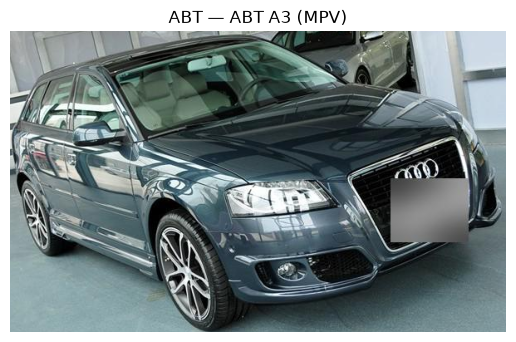

In [15]:
df = pd.read_csv("../../data/manifests/compcars_manifest.csv")
row = df.iloc[2]

image_path = row["image_path"].replace("\\", "/")   # ← fixed, no extra ../../
x1, y1, x2, y2 = ast.literal_eval(row["bbox"]) if isinstance(row["bbox"], str) else row["bbox"]

image = cv2.imread(image_path)
if image is None:
    raise FileNotFoundError(f"Could not load {image_path}")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)
crop = image[y1:y2, x1:x2]

plt.imshow(crop)
plt.title(f'{row["make_name"]} — {row["model_name"]} ({row["car_type_name"]})')
plt.axis("off")
plt.show()

In [16]:
with open("../../data/raw/compcars/train_test_split/classification/train.txt") as f:
    for _ in range(5):
        print(f.readline())

78/1/2010/439374a1456969.jpg

78/1/2010/6c5730eb35dbfc.jpg

78/1/2014/a2b9bfe21409f4.jpg

78/1/2013/043602fa21a621.jpg

78/1/2012/ccc640bfa095e3.jpg



In [ ]:
def load_split_set(path: str) -> set:
    with open(path) as f:
        return set(line.strip() for line in f if line.strip())

def get_relative_key(image_path: str) -> str:
   
    normalized = image_path.replace("\\", "/")
    match = re.search(r"(\d+/\d+/\d+/[^/]+\.jpg)$", normalized)
    return match.group(1) if match else None


train_set = load_split_set("../../data/raw/compcars/train_test_split/classification/train.txt")
test_set = load_split_set("../../data/raw/compcars/train_test_split/classification/test.txt")

# Build the relative key for each manifest row
df["relative_key"] = df["image_path"].apply(get_relative_key)

# Assign split
def assign_split(key):
    if key in train_set:
        return "train"
    elif key in test_set:
        return "test"
    else:
        return None  

df["split"] = df["relative_key"].apply(assign_split)

print(df["split"].value_counts(dropna=False))

split
NaN      105801
train     16003
test      14922
Name: count, dtype: int64


In [19]:
unmatched = df[df["split"].isna()]
print(len(unmatched))
print(unmatched[["image_path", "relative_key"]].head(10))

105801
                                          image_path  \
0  ../../data/raw/compcars/image\1\1101\2011\07b9...   
1  ../../data/raw/compcars/image\1\1101\2011\2272...   
2  ../../data/raw/compcars/image\1\1101\2011\3a62...   
3  ../../data/raw/compcars/image\1\1101\2011\5133...   
4  ../../data/raw/compcars/image\1\1101\2011\6632...   
5  ../../data/raw/compcars/image\1\1101\2011\67c2...   
6  ../../data/raw/compcars/image\1\1101\2011\7a62...   
7  ../../data/raw/compcars/image\1\1101\2011\8a8a...   
8  ../../data/raw/compcars/image\1\1101\2011\8cef...   
9  ../../data/raw/compcars/image\1\1101\2011\916c...   

                     relative_key  
0  1/1101/2011/07b90decb92ba6.jpg  
1  1/1101/2011/2272c7d324cf79.jpg  
2  1/1101/2011/3a62131af5fe8e.jpg  
3  1/1101/2011/5133ca181b82af.jpg  
4  1/1101/2011/6632ec1c2f7f87.jpg  
5  1/1101/2011/67c264ccb6f982.jpg  
6  1/1101/2011/7a6282504fdd2c.jpg  
7  1/1101/2011/8a8a9bc65fab0b.jpg  
8  1/1101/2011/8cef236c1c21c4.jpg  
9  1/1101/2011/9

In [20]:
print(unmatched["relative_key"].isna().sum())  # how many failed to extract ANY key at all

343


In [21]:
# Do the unmatched images belong to models that just aren't in the split at all?
print(unmatched["make_name"].value_counts().head(10))
print(df[df["split"].notna()]["make_name"].nunique(), "makes in split")
print(df["make_name"].nunique(), "makes in full manifest")

make_name
Benz          4092
Toyota        3768
Volkswagen    3394
Ford          3233
Hyundai       3100
Nissan        2996
BWM           2887
Audi          2829
Chevy         2719
KIA           2320
Name: count, dtype: int64
75 makes in split
162 makes in full manifest


In [22]:
df_classification = df[df["split"].notna()].copy()
print(len(df_classification))
print(df_classification["split"].value_counts())
print(df_classification["make_name"].nunique(), "makes")

df_classification.to_csv("../../data/manifests/compcars_classification.csv", index=False)

30925
split
train    16003
test     14922
Name: count, dtype: int64
75 makes


Create manifest for surveillance data now

In [20]:
color_data = loadmat("../../data/raw/compcars/sv_data/color_list.mat")
print(color_data.keys())

name_data = loadmat("../../data/raw/compcars/sv_data/sv_make_model_name.mat")
print(name_data.keys())

dict_keys(['__header__', '__version__', '__globals__', 'color_list'])
dict_keys(['__header__', '__version__', '__globals__', 'sv_make_model_name'])


In [21]:
print(color_data["color_list"][:5])
print(color_data["color_list"].shape)

print(name_data["sv_make_model_name"][:5])
print(name_data["sv_make_model_name"].shape)

[[array(['1/d5dcefddcde927.jpg'], dtype='<U20') array([[1]], dtype=uint8)]
 [array(['1/a751752e438d65.jpg'], dtype='<U20') array([[2]], dtype=uint8)]
 [array(['1/c5f1d0a1f04fc9.jpg'], dtype='<U20') array([[9]], dtype=uint8)]
 [array(['1/874f996b927cff.jpg'], dtype='<U20') array([[0]], dtype=uint8)]
 [array(['1/74fe86d0eea1cc.jpg'], dtype='<U20') array([[1]], dtype=uint8)]]
(44481, 2)
[[array(['Besturn'], dtype='<U7') array(['Besturn X80'], dtype='<U11')
  array([[366]], dtype=uint16)]
 [array(['Hafei'], dtype='<U5') array(['Lubao'], dtype='<U5')
  array([[716]], dtype=uint16)]
 [array(['Audi'], dtype='<U4') array(['Audi Q5'], dtype='<U7')
  array([[5]], dtype=uint8)]
 [array(['Audi'], dtype='<U4') array(['Audi Q3'], dtype='<U7')
  array([[4]], dtype=uint8)]
 [array(['Audi'], dtype='<U4') array(['Audi A7'], dtype='<U7')
  array([[26]], dtype=uint8)]]
(281, 3)


In [22]:
from vehicle_id.data.surveillance_manifest import build_surveillance_manifest

df = build_surveillance_manifest(sv_root="../../data/raw/compcars/sv_data")
print(len(df))
df.head()
print(df["split"].value_counts(dropna=False))
print(df["color_name"].value_counts(dropna=False))

44481
split
train    31148
test     13333
Name: count, dtype: int64
color_name
black           14911
silver          12569
white            7570
red              3627
blue             1876
brown            1460
yellow           1123
champagne         829
green             255
purple            221
unrecognized       40
Name: count, dtype: int64


In [23]:
# Drop the 40 "unrecognized" colour rows for training purposes
df_clean = df[df["color_name"] != "unrecognized"].copy()
df_clean.to_csv("../../data/manifests/compcars_surveillance_classification.csv", index=False)
print(len(df_clean))

44441


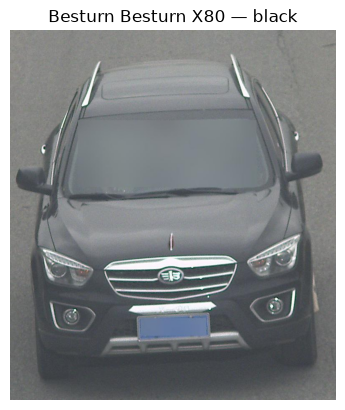

In [24]:
row = df.iloc[0]
image_path = row["image_path"].replace("\\", "/")

image = cv2.imread(image_path)
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

plt.imshow(image)
plt.title(f'{row["make_name"]} {row["model_name"]} — {row["color_name"]}')
plt.axis("off")
plt.show()

In [25]:
df_clean = df[df["color_name"] != "unrecognized"].copy()
df_clean.to_csv("../../data/manifests/compcars_surveillance_classification.csv", index=False)
print(len(df_clean))

44441


Manifest -> Dataset

In [26]:
from vehicle_id.attributes.dataset import CompCarsMakeDataset

df = pd.read_csv("../../data/manifests/compcars_classification.csv")
train_df = df[df["split"] == "train"]

dataset = CompCarsMakeDataset(train_df, label_col="make_name")

print(len(dataset), "images")
print(len(dataset.classes), "classes")

image, label = dataset[0]
print(image.shape, label)

16003 images
75 classes
torch.Size([3, 224, 224]) 29


In [27]:
dataset_bodyshape = CompCarsMakeDataset(train_df, label_col="car_type_name")
image, label = dataset_bodyshape[0]
print(image.shape, label, len(dataset_bodyshape.classes))

torch.Size([3, 224, 224]) 5 12


In [28]:
print(train_df["car_type_name"].value_counts(dropna=False))
print(train_df["car_type_name"].unique())

car_type_name
sedan                  6386
SUV                    3438
hatchback              2985
sports                  758
MPV                     672
convertible             499
fastback                489
estate                  256
hardtop convertible     214
minibus                 141
pickup                   83
crossover                82
Name: count, dtype: int64
<StringArray>
[           'fastback',               'sedan',         'convertible',
           'hatchback',                 'SUV', 'hardtop convertible',
              'estate',              'sports',                 'MPV',
             'minibus',              'pickup',           'crossover']
Length: 12, dtype: str


In [29]:
import random

for i in random.sample(range(len(dataset)), 20):
    image, label = dataset[i]
    assert image.shape == (3, 224, 224), f"Bad shape at {i}: {image.shape}"

print("20 random samples passed")

20 random samples passed


In [30]:
print(train_df["car_type"].value_counts(dropna=False))

car_type
1    16003
Name: count, dtype: int64


In [31]:
sample_paths = df.sample(5)["label_path"] if "label_path" in df.columns else None
# if label_path isn't stored, reconstruct from image_path pattern instead

In [32]:


sample_label_paths = [
    "../../data/raw/compcars/label/2/1205/2015",  # pick a make/model DIFFERENT from make_id=1
]

# List whatever's actually in a different make's label folder
for make_id in ["2", "10", "50"]:
    make_dir = f"../../data/raw/compcars/label/{make_id}"
    if os.path.exists(make_dir):
        # descend into first model/year found
        model_id = os.listdir(make_dir)[0]
        year = os.listdir(os.path.join(make_dir, model_id))[0]
        year_dir = os.path.join(make_dir, model_id, year)
        fname = os.listdir(year_dir)[0]
        path = os.path.join(year_dir, fname)
        with open(path) as f:
            print(make_id, "->", f.read().replace("\n", " | "))

2 -> 1 | 1 | 157 181 876 614 | 
10 -> 2 | 1 | 177 179 726 522 | 
50 -> 4 | 1 | 6 231 901 626 | 


In [33]:
counts = {}
for make_id in os.listdir("../../data/raw/compcars/label")[:30]:  # 30 different makes
    make_dir = f"../../data/raw/compcars/label/{make_id}"
    model_id = os.listdir(make_dir)[0]
    year = os.listdir(os.path.join(make_dir, model_id))[0]
    year_dir = os.path.join(make_dir, model_id, year)
    fname = os.listdir(year_dir)[0]
    path = os.path.join(year_dir, fname)
    with open(path) as f:
        lines = f.read().splitlines()
        car_type = lines[1]
        counts[car_type] = counts.get(car_type, 0) + 1

print(counts)

{'1': 30}


In [34]:
attrs = pd.read_csv(
    "../../data/raw/compcars/misc/attributes.txt",
    sep=r"\s+",
    header=0
)
print(attrs.head())
print(attrs["type"].value_counts())

   model_id  maximum_speed  displacement  door_number  seat_number  type
0         1            235           1.8            5            5     4
1         2            220           1.8            4            5     3
2         3            228           2.0            4            5     3
3         4            230           2.0            5            5     2
4         5            234           3.0            5            5     2
type
0     748
3     290
2     200
4     158
5      71
1      60
10     56
8      46
6      22
9      22
12     16
7      14
11     13
Name: count, dtype: int64


In [35]:
df = df.merge(attrs[["model_id", "type"]], on="model_id", how="left")

In [36]:
print(df["type"].value_counts(dropna=False))

KeyError: 'type'

In [19]:
print(df.columns.tolist())

['image_path', 'make_id', 'model_id', 'year', 'bbox', 'viewpoint', 'car_type', 'make_name', 'model_name', 'car_type_name', 'relative_key', 'split', 'type_x', 'type_y']


In [37]:

df = pd.read_csv("../../data/manifests/compcars_manifest.csv")

# Merge attrs exactly once
df["model_id"] = df["model_id"].astype(int)
attrs["model_id"] = attrs["model_id"].astype(int)
df = df.merge(attrs[["model_id", "type"]], on="model_id", how="left")

print(df.columns.tolist())  # confirm only ONE "type" column now

['image_path', 'make_id', 'model_id', 'year', 'bbox', 'viewpoint', 'car_type', 'type_x', 'type_y']


In [18]:
car_type_mat = loadmat("../../data/raw/compcars/misc/car_type.mat")["types"]

def resolve_type_name(type_id):
    if pd.isna(type_id):
        return None
    try:
        idx = int(type_id) - 1
        return str(car_type_mat[idx][0])
    except (IndexError, ValueError):
        return None

df["car_type_name"] = df["type"].apply(resolve_type_name)
print(df["car_type_name"].value_counts(dropna=False))

KeyError: 'type'

In [15]:
print(len(car_type_mat))
for i, entry in enumerate(car_type_mat):
    print(i, entry)

1
0 [array(['MPV'], dtype='<U3') array(['SUV'], dtype='<U3')
 array(['sedan'], dtype='<U5') array(['hatchback'], dtype='<U9')
 array(['minibus'], dtype='<U7') array(['fastback'], dtype='<U8')
 array(['estate'], dtype='<U6') array(['pickup'], dtype='<U6')
 array(['hardtop convertible'], dtype='<U19')
 array(['sports'], dtype='<U6') array(['crossover'], dtype='<U9')
 array(['convertible'], dtype='<U11')]


In [16]:
print(car_type_mat[0])
print(type(car_type_mat[0]))
print(car_type_mat[0][0])
print(type(car_type_mat[0][0]))

[array(['MPV'], dtype='<U3') array(['SUV'], dtype='<U3')
 array(['sedan'], dtype='<U5') array(['hatchback'], dtype='<U9')
 array(['minibus'], dtype='<U7') array(['fastback'], dtype='<U8')
 array(['estate'], dtype='<U6') array(['pickup'], dtype='<U6')
 array(['hardtop convertible'], dtype='<U19')
 array(['sports'], dtype='<U6') array(['crossover'], dtype='<U9')
 array(['convertible'], dtype='<U11')]
<class 'numpy.ndarray'>
['MPV']
<class 'numpy.ndarray'>


In [ ]:
def resolve_type_name(type_id):
    if pd.isna(type_id) or int(type_id) == 0:
        return None
    try:
        idx = int(type_id) - 1
        return str(car_type_mat[0][idx][0])
    except (IndexError, ValueError):
        return None

df["car_type_name"] = df["type"].apply(resolve_type_name)
print(df["car_type_name"].value_counts(dropna=False))

car_type_name
sedan                  12324
SUV                     6669
hatchback               5780
sports                  1474
MPV                     1289
convertible              971
fastback                 941
estate                   491
hardtop convertible      407
minibus                  268
pickup                   158
crossover                153
Name: count, dtype: int64


In [18]:
df_classification = df[df["split"].notna()].copy()
df_classification.to_csv("../../data/manifests/compcars_classification.csv", index=False)
print(len(df_classification))

30925


In [ ]:
train_df = df_classification[df_classification["split"] == "train"]
dataset_bodyshape = CompCarsMakeDataset(train_df, label_col="car_type_name")

print(len(dataset_bodyshape.classes), "classes")
image, label = dataset_bodyshape[0]
print(image.shape, label)

12 classes
torch.Size([3, 224, 224]) 5


In [20]:


df = pd.read_csv("../../data/manifests/compcars_classification.csv")
train_df = df[df["split"] == "train"]

# Test both label columns you actually use
for label_col in ["make_name", "car_type_name"]:
    dataset = CompCarsMakeDataset(train_df, label_col=label_col)
    image, label = dataset[0]
    print(f"{label_col}: {len(dataset)} images, {len(dataset.classes)} classes, "
          f"sample shape {image.shape}, sample label {label}")
    assert image.shape == (3, 224, 224)
    assert 0 <= label < len(dataset.classes)

print("Structural checks passed")

make_name: 16003 images, 75 classes, sample shape torch.Size([3, 224, 224]), sample label 29
car_type_name: 16003 images, 12 classes, sample shape torch.Size([3, 224, 224]), sample label 5
Structural checks passed


In [ ]:
for label_col in ["make_name", "car_type_name"]:
    dataset = CompCarsMakeDataset(train_df, label_col=label_col)
    for i in random.sample(range(len(dataset)), 50):
        image, label = dataset[i]
        assert image.shape == (3, 224, 224), f"Bad shape at {i}: {image.shape}"
        assert 0 <= label < len(dataset.classes), f"Bad label at {i}: {label}"

print("50 random samples passed for both label columns")

50 random samples passed for both label columns


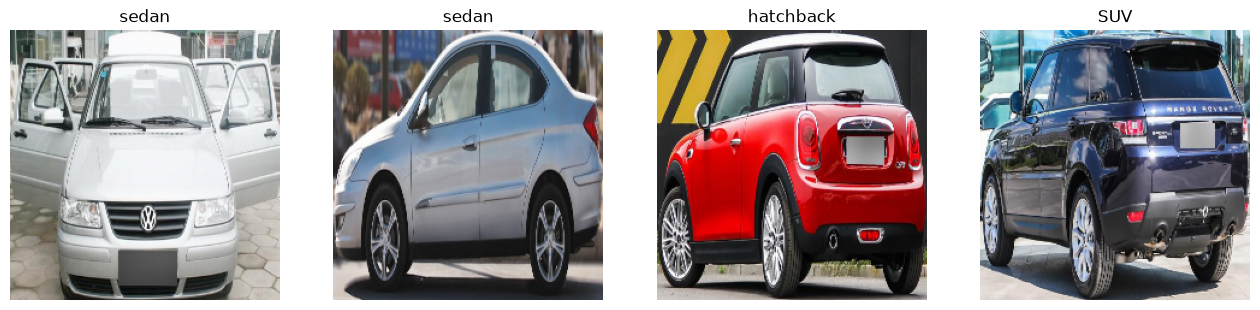

In [22]:


dataset = CompCarsMakeDataset(train_df, label_col="car_type_name")
idx_to_class = {v: k for k, v in dataset.class_to_idx.items()}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax in axes:
    i = random.randint(0, len(dataset) - 1)
    image, label = dataset[i]
    img_display = image.permute(1, 2, 0).numpy()
    ax.imshow(img_display)
    ax.set_title(idx_to_class[label])
    ax.axis("off")
plt.show()

In [4]:
sv_df = pd.read_csv("../../data/manifests/compcars_surveillance_classification.csv")
sv_train_df = sv_df[sv_df["split"] == "train"]

dataset_colour = CompCarsMakeDataset(sv_train_df, label_col="color_name")

print(len(dataset_colour), "images")
print(len(dataset_colour.classes), "classes:", dataset_colour.classes)

image, label = dataset_colour[0]
print(image.shape, label)

31118 images
10 classes: ['black', 'blue', 'brown', 'champagne', 'green', 'purple', 'red', 'silver', 'white', 'yellow']
torch.Size([3, 224, 224]) 0


In [6]:
for i in random.sample(range(len(dataset_colour)), 50):
    image, label = dataset_colour[i]
    assert image.shape == (3, 224, 224), f"Bad shape at {i}"
    assert 0 <= label < len(dataset_colour.classes), f"Bad label at {i}"

print("50 random samples passed")

50 random samples passed


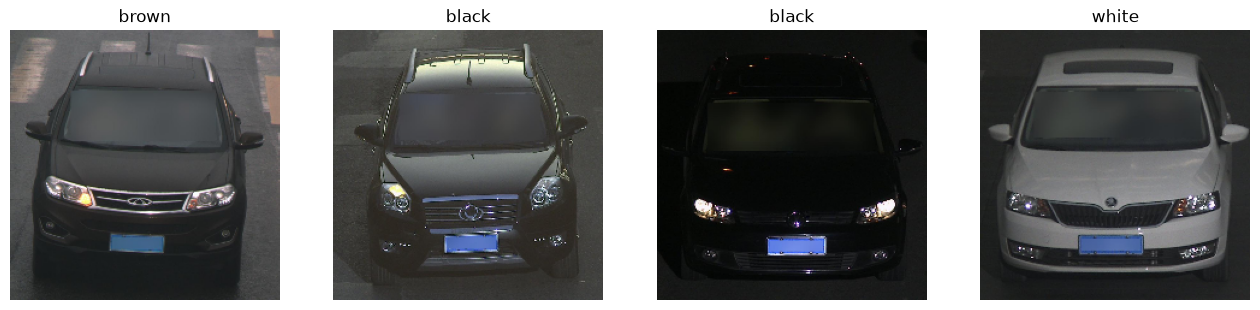

In [7]:
idx_to_class = {v: k for k, v in dataset_colour.class_to_idx.items()}

fig, axes = plt.subplots(1, 4, figsize=(16, 4))
for ax in axes:
    i = random.randint(0, len(dataset_colour) - 1)
    image, label = dataset_colour[i]
    img_display = image.permute(1, 2, 0).numpy()
    ax.imshow(img_display)
    ax.set_title(idx_to_class[label])
    ax.axis("off")
plt.show()